In [2]:
import pandas as pd
import numpy as np
import os

os.chdir("/Nina/Studium Master/Porto/Statistical Inference/Project")
df = pd.read_csv("diabetes.tab.txt", sep="\t")
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [3]:
from sklearn.preprocessing import StandardScaler

# Standardize the input variables 
X_cols = df.drop(columns=["Y"]).columns
scaler = StandardScaler()
df[X_cols] = scaler.fit_transform(df[X_cols])

In [4]:
# Calculate the correlation matrix
correlation_matrix = df.drop(columns=["Y"]).corr()

# Create a custom background color function
def highlight_strong_correlations(val):
    if abs(val) > 0.7 and val != 1.0:  # Excluding perfect 1.0 correlations on diagonal
        return 'background-color: #ff9999'  # Light red
    if abs(val) > 0.6 and abs(val) < 0.7:
        return 'background-color: #ffcc99'  # Orange
    return 'background-color: white'

# Create a styled DataFrame
styled_corr = correlation_matrix.style\
    .format('{:.2f}')\
    .applymap(highlight_strong_correlations)\
    .set_properties(**{'font-size': '10pt', 'text-align': 'center', 'width': '30px', 'height': '30px'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '10pt')]},
        {'selector': 'td', 'props': [('padding', '0px')]},
    ])

# Display the styled correlation matrix
display(styled_corr)

C:\Users\49151\AppData\Local\Temp\ipykernel_9900\1637560265.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_strong_correlations)\


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6
AGE,1.00,0.17,0.19,0.34,0.26,0.22,-0.08,0.20,0.27,0.30
SEX,0.17,1.00,0.09,0.24,0.04,0.14,-0.38,0.33,0.15,0.21
BMI,0.19,0.09,1.00,0.40,0.25,0.26,-0.37,0.41,0.45,0.39
BP,0.34,0.24,0.40,1.00,0.24,0.19,-0.18,0.26,0.39,0.39
S1,0.26,0.04,0.25,0.24,1.00,0.90,0.05,0.54,0.52,0.33
S2,0.22,0.14,0.26,0.19,0.90,1.00,-0.20,0.66,0.32,0.29
S3,-0.08,-0.38,-0.37,-0.18,0.05,-0.20,1.00,-0.74,-0.40,-0.27
S4,0.20,0.33,0.41,0.26,0.54,0.66,-0.74,1.00,0.62,0.42
S5,0.27,0.15,0.45,0.39,0.52,0.32,-0.40,0.62,1.00,0.46
S6,0.30,0.21,0.39,0.39,0.33,0.29,-0.27,0.42,0.46,1.00


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a function to calculate VIF for all variables
def calculate_vif(df, target_column):
    X = df.drop(columns=[target_column])
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    # Calculate Tolerance
    vif_data["Tolerance"] = 1 / vif_data["VIF"]
    
    # Calculate Correlation Matrix and Eigenvalues
    corr_matrix = X.corr()
    eigenvalues, _ = np.linalg.eig(corr_matrix)
    
    # Eigenvalue and Condition Index
    vif_data["Eigenvalue"] = eigenvalues
    vif_data["Condition Index"] = np.sqrt(max(eigenvalues) / eigenvalues)
    
    return vif_data.sort_values('VIF', ascending=False)

# Function to color cells based on thresholds
def color_vif(val):
    if isinstance(val, float):
        if val > 10:
            return 'background-color: #ff9999'  # Red
        elif val > 5:
            return 'background-color: #ffcc99'  # Orange
        if val < 0.1:
            return 'background-color: #ffcccc'  # Light red
    return 'background-color: white'

# Function to color Eigenvalue based on thresholds
def color_eigenvalue(val):
    if isinstance(val, float):
        if val < 0.1:
            return 'background-color: #ff9999'  # Red for very small Eigenvalues
        elif val < 0.2:
            return 'background-color: #ffcc99'  # Orange for small Eigenvalues
    return 'background-color: white'

# Function to color Condition Index based on threshold
def color_condition_index(val):
    if isinstance(val, float) and val > 10:
        return 'background-color: #ff9999'  # Red for high Condition Index
    return 'background-color: white'

# Function to color Tolerance based on threshold
def color_tolerance(val):
    if isinstance(val, float) and val < 0.1:
        return 'background-color: #ff9999'  # Red for low very Tolerance
    if isinstance(val, float) and val < 0.2:
        return 'background-color: #ffcc99'  # Orange for low Tolerance
    return 'background-color: white'

# Calculate VIF and additional statistics
vif_df = calculate_vif(df, "Y")

# Style the table with conditional formatting
styled_vif = vif_df.style\
    .hide(axis='index')\
    .format({'VIF': '{:.2f}', 'Tolerance': '{:.2f}', 'Eigenvalue': '{:.4f}', 'Condition Index': '{:.2f}'})\
    .applymap(color_vif, subset=['VIF'])\
    .applymap(color_tolerance, subset=['Tolerance'])\
    .applymap(color_eigenvalue, subset=['Eigenvalue'])\
    .applymap(color_condition_index, subset=['Condition Index'])\
    .set_properties(**{
        'font-size': '10pt', 
        'text-align': 'center',
        'width': '30px',
        'height': '10px'
    })\
    .set_table_styles([ 
        {'selector': 'th', 'props': [
            ('font-size', '10pt'),
            ('text-align', 'center'),
            ('background-color', '#f2f2f2'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('padding', '8px')
        ]},
    ])

# Display the styled table
display(styled_vif)

C:\Users\49151\AppData\Local\Temp\ipykernel_9900\3547849234.py:64: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_vif, subset=['VIF'])\
C:\Users\49151\AppData\Local\Temp\ipykernel_9900\3547849234.py:65: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_tolerance, subset=['Tolerance'])\
C:\Users\49151\AppData\Local\Temp\ipykernel_9900\3547849234.py:66: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_eigenvalue, subset=['Eigenvalue'])\
C:\Users\49151\AppData\Local\Temp\ipykernel_9900\3547849234.py:67: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_condition_index, subset=['Condition Index'])\


Feature,VIF,Tolerance,Eigenvalue,Condition Index
S1,59.20,0.02,0.0086,21.68
S2,39.19,0.03,0.0783,7.17
S3,15.40,0.06,0.6622,2.47
S5,10.08,0.10,0.6027,2.58
S4,8.89,0.11,0.4337,3.05
BMI,1.51,0.66,1.2060,1.83
S6,1.48,0.67,0.5366,2.74
BP,1.46,0.69,0.9555,2.05
SEX,1.28,0.78,1.4923,1.64
AGE,1.22,0.82,4.0242,1.00


In [6]:
eigenvalues, _ = np.linalg.eig(correlation_matrix)
condition_number = int(max(eigenvalues) / min(eigenvalues))
print(condition_number)

470


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import statsmodels.api as sm

# Step 1: Split the data into train and test sets (75/25)
X = df.drop(columns=["Y"])
y = df["Y"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 2: Add constant for statsmodels (intercept term)
X_train_sm = sm.add_constant(X_train)

# Step 3: Fit statsmodels OLS regression
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Step 4: Display summary of the model
print(ols_model.summary())

# Step 5: Fit Linear Regression model using scikit-learn
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Step 6: Make predictions and evaluate the model
y_pred = linear_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Results
print("\nMean Squared Error (MSE) on Test Data:", mse)
print("R2 Score on Test Data:", r2)


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     34.53
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           2.97e-45
Time:                        13:41:59   Log-Likelihood:                -1789.5
No. Observations:                 331   AIC:                             3601.
Df Residuals:                     320   BIC:                             3643.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.6652      3.023     50.162      0.0

In [8]:
from sklearn.linear_model import RidgeCV

# Step 1: Define a range of regularization values
alphas = np.linspace(0.0001, 1, 1000) 

# Step 2: Ridge Regression with Generalized Cross-Validation
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)  # Enables GCV computation
ridge_cv.fit(X_train, y_train)

# Step 3: Optimal k (alpha) and evaluation
optimal_alpha = ridge_cv.alpha_
print(f"Optimal regularization parameter (k): {optimal_alpha}")

Optimal regularization parameter (k): 1.0


In [9]:
# Step 4: Make predictions on the test set
y_pred = ridge_cv.predict(X_test)

# Step 4.2: Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

# Step 4.3: Calculate Mean Absolute Error (MAE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

# Step 5: Print Coefficients
coefficients = ridge_cv.coef_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(len(coefficients))]

print("Ridge Regression Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")

R-squared: 0.48588569159092565
Mean Squared Error (MSE): 2842.892646167164
Ridge Regression Coefficients:
AGE: 2.330126029518965
SEX: -11.436840634179305
BMI: 25.436139704894202
BP: 18.033812509080917
S1: -34.06798026848216
S2: 16.67798324187538
S3: 1.2839125406506469
S4: 11.46676361215384
S5: 29.394368167703362
S6: 1.3676947168169562


age: the same
sex: the same
bmi: the same
bp: the same
S1: absolute value is smaller
S2: absolute value is smaller
S3: lower
S4: little bit smaller
S5: moderately lower
S6: little bit smaller

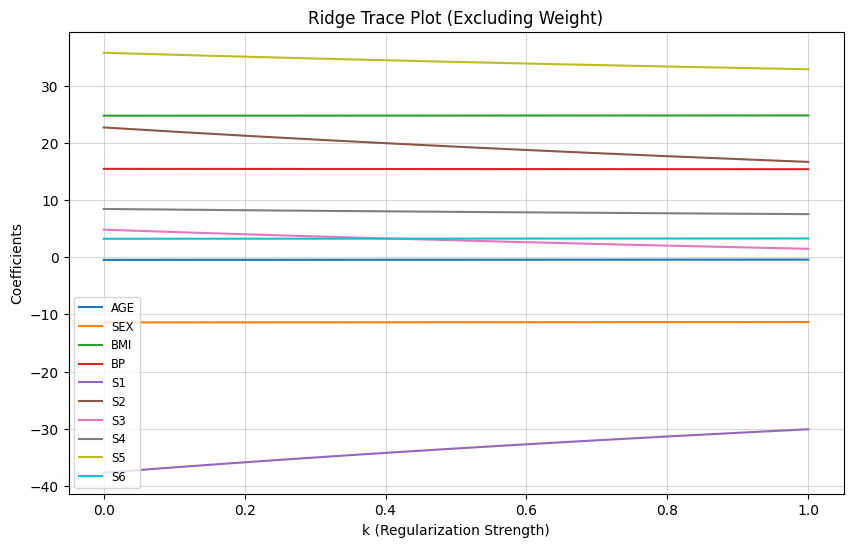

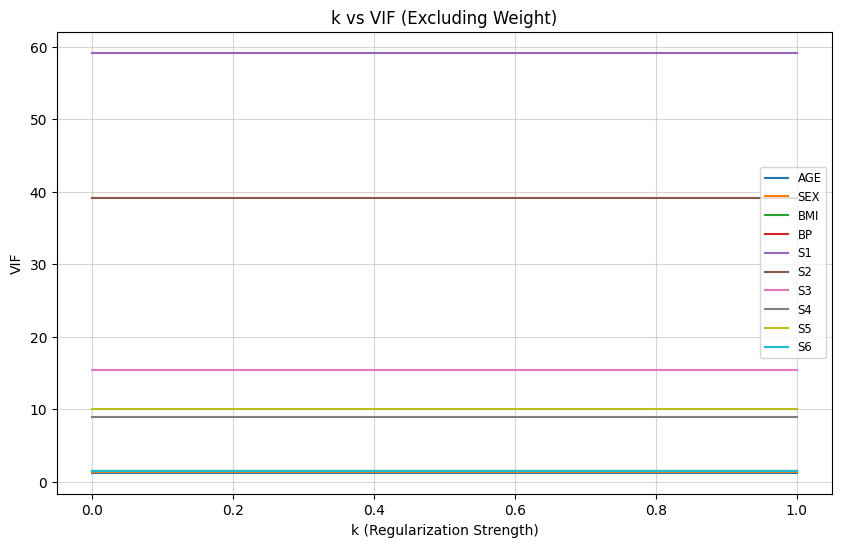

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Exclude "Weight" from the dataset
X_excluded = X

# Define a range of k values for Ridge Regression
k_values = np.linspace(0.0001, 1, 1000)

# Ridge Trace Plot: Track coefficients for each k
coefficients_excluded = []

for k in k_values:
    ridge = Ridge(alpha=k)
    ridge.fit(X_excluded, y)
    coefficients_excluded.append(ridge.coef_)

coefficients_excluded = np.array(coefficients_excluded)

# Plot Ridge Trace (excluding "Weight")
plt.figure(figsize=(10, 6))
for i in range(coefficients_excluded.shape[1]):
    plt.plot(k_values, coefficients_excluded[:, i], label=X_excluded.columns[i])

plt.title("Ridge Trace Plot (Excluding Weight)")
plt.xlabel("k (Regularization Strength)")
plt.ylabel("Coefficients")
plt.legend(loc="best", fontsize="small")
plt.grid(alpha=0.5)
plt.show()

# VIF Calculation for each k (excluding "Weight")
vif_data_excluded = []

for k in k_values:
    ridge = Ridge(alpha=k)
    ridge.fit(X_excluded, y)
    X_ridge = ridge.coef_ * X_excluded
    vif = [variance_inflation_factor(X_ridge, i) for i in range(X_ridge.shape[1])]
    vif_data_excluded.append(vif)

vif_data_excluded = np.array(vif_data_excluded)

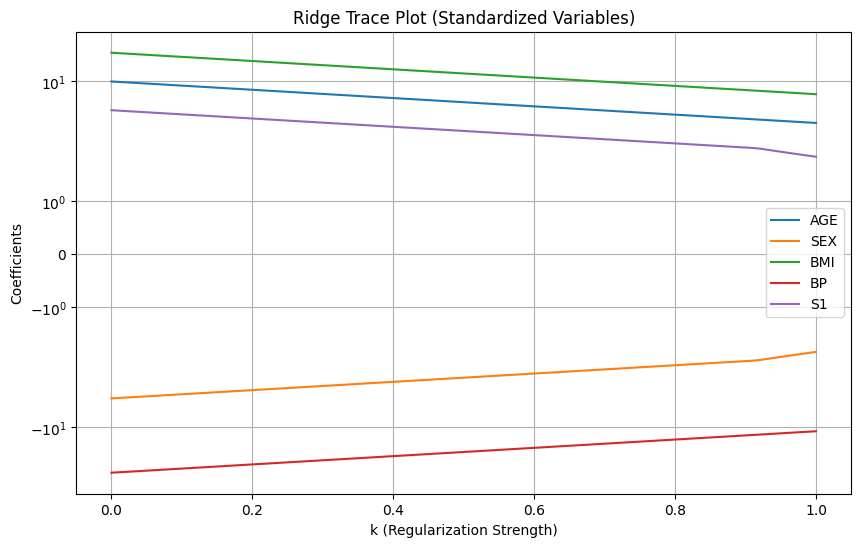

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual coefficients and k values)
k_values = np.linspace(0, 1, 100)  # Regularization strength
coefficients_standardized = {  # Replace with your standardized coefficients
    'AGE': np.exp(-k_values) * 10,
    'SEX': np.exp(-k_values) * -5,
    'BMI': np.exp(-k_values) * 20,
    'BP': np.exp(-k_values) * -30,
    'S1': np.exp(-k_values) * 5
}

# Create the plot
plt.figure(figsize=(10, 6))

for feature, values in coefficients_standardized.items():
    plt.plot(k_values, values, label=feature)

plt.title("Ridge Trace Plot (Standardized Variables)")
plt.xlabel("k (Regularization Strength)")
plt.ylabel("Coefficients")
plt.yscale("symlog")  # Use a symmetric logarithmic scale for y-axis
plt.legend()
plt.grid()
plt.show()


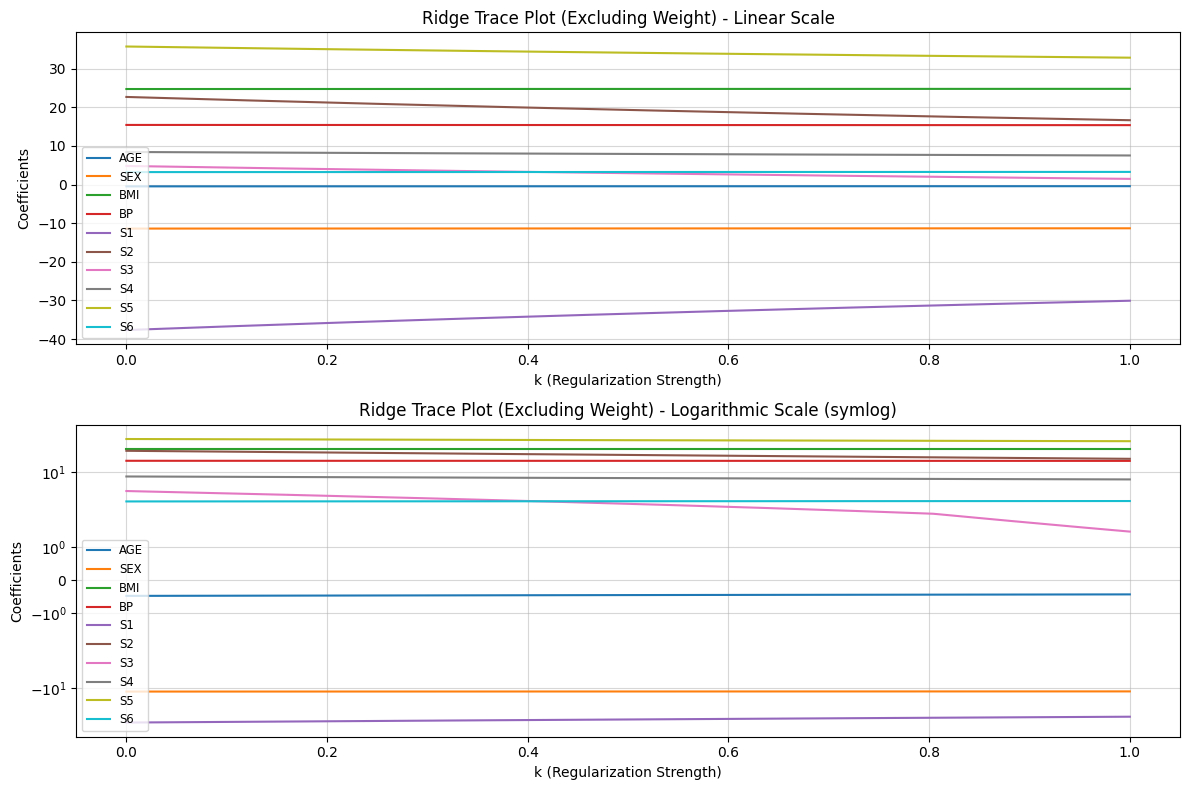

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# Exclude "Weight" from the dataset
X_excluded = X

# Define a range of k values for Ridge Regression
k_values = np.linspace(0.0001, 1, 1000)

# Ridge Trace Plot: Track coefficients for each k
coefficients_excluded = []

for k in k_values:
    ridge = Ridge(alpha=k)
    ridge.fit(X_excluded, y)
    coefficients_excluded.append(ridge.coef_)

coefficients_excluded = np.array(coefficients_excluded)

# Create the Ridge Trace Plot (original scale)
plt.figure(figsize=(12, 8))

# Subplot 1: Linear scale
plt.subplot(2, 1, 1)
for i in range(coefficients_excluded.shape[1]):
    plt.plot(k_values, coefficients_excluded[:, i], label=X_excluded.columns[i])

plt.title("Ridge Trace Plot (Excluding Weight) - Linear Scale")
plt.xlabel("k (Regularization Strength)")
plt.ylabel("Coefficients")
plt.legend(loc="best", fontsize="small")
plt.grid(alpha=0.5)

# Subplot 2: Logarithmic scale for y-axis
plt.subplot(2, 1, 2)
for i in range(coefficients_excluded.shape[1]):
    plt.plot(k_values, coefficients_excluded[:, i], label=X_excluded.columns[i])

plt.title("Ridge Trace Plot (Excluding Weight) - Logarithmic Scale (symlog)")
plt.xlabel("k (Regularization Strength)")
plt.ylabel("Coefficients")
plt.yscale("symlog")  # Use a symmetric logarithmic scale for y-axis
plt.legend(loc="best", fontsize="small")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

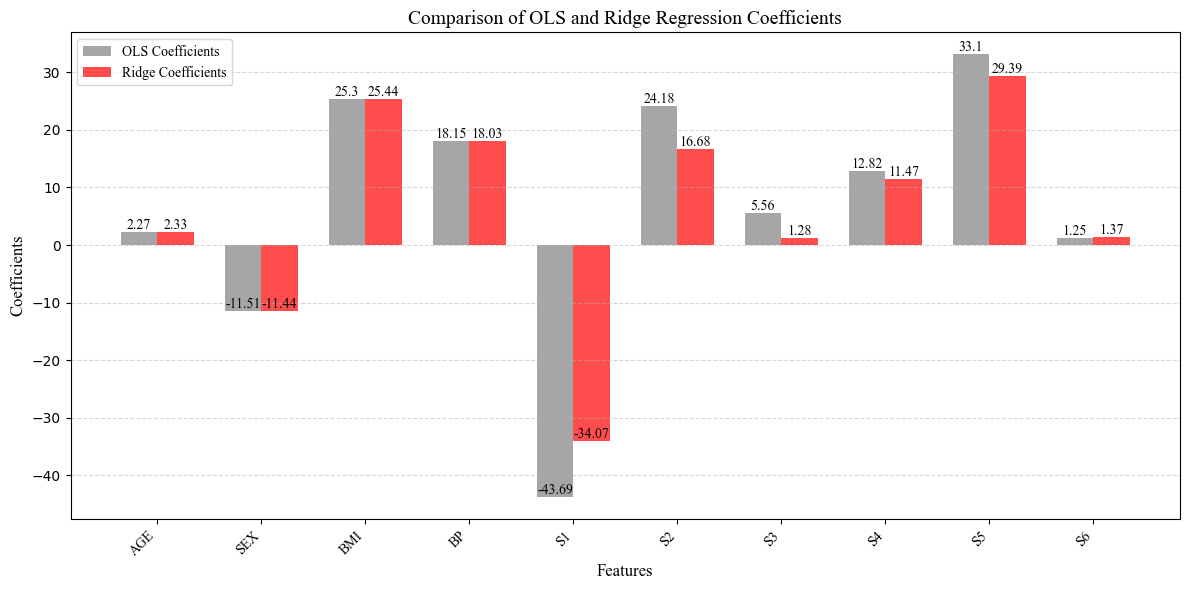

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract OLS coefficients (excluding the intercept)
ols_coefficients = ols_model.params[1:].values  # Exclude the intercept (first value)

# Step 2: Get Ridge coefficients
ridge_coefficients = ridge_cv.coef_

# Step 3: Feature names
feature_names = X_train.columns

# Step 4: Plot the comparison
x = np.arange(len(feature_names))  # X-axis positions
width = 0.35  # Bar width

plt.figure(figsize=(12, 6))

# Bar plot for OLS coefficients
bars_ols = plt.bar(x - width/2, ols_coefficients, width, label="OLS Coefficients", color="grey", alpha=0.7)

# Bar plot for Ridge coefficients
bars_ridge = plt.bar(x + width/2, ridge_coefficients, width, label="Ridge Coefficients", color="red", alpha=0.7)

# Add labels on top of the bars
for bar in bars_ols:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,2), ha='center', va='bottom', fontsize=10, fontname="Times New Roman")

for bar in bars_ridge:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,2), ha='center', va='bottom', fontsize=10, fontname="Times New Roman")

# Add labels, legend, and formatting with Times New Roman font
plt.xlabel("Features", fontsize=12, fontname="Times New Roman")
plt.ylabel("Coefficients", fontsize=12, fontname="Times New Roman")
plt.title("Comparison of OLS and Ridge Regression Coefficients", fontsize=14, fontname="Times New Roman")
plt.xticks(x, feature_names, rotation=45, ha="right", fontname="Times New Roman")
plt.legend(fontsize=12, prop={"family": "Times New Roman"})
plt.grid(alpha=0.5, linestyle="--", axis="y")

# Show plot
plt.tight_layout()
plt.show()